# Notebook 02 — Exploratory Data Analysis & Preprocessing

## Human-to-Gorilla Zoonotic Disease Transmission Risk Analysis

---

### Purpose
- Load and inspect all five raw datasets
- Assess data quality (missingness, types, outliers)
- Produce descriptive statistics and initial visualizations
- Clean and merge datasets into processed outputs for downstream notebooks

### Prerequisites
Run `01_setup_and_data_generation.ipynb` first.

### Outputs
- `data/processed/gorilla_health_enriched.csv` — health events + demographics
- `data/processed/tourist_enriched.csv` — tourist visits + climate
- `data/processed/daily_summary.csv` — daily cross-table aggregation

## Cell 1 — Imports

In [18]:
import os
import sys
import sqlite3
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.viz_utils import set_style, save_fig, PALETTE, AGE_ORDER

set_style()

RAW_DIR  = PROJECT_ROOT / 'data' / 'raw'
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR  = PROJECT_ROOT / 'outputs' / 'figures'
PROC_DIR.mkdir(parents=True, exist_ok=True)

print('EDA notebook ready.')

EDA notebook ready.


## Cell 2 — Load All Datasets

In [19]:
# ── Load raw CSVs ─────────────────────────────────────────────────────────────
demographics_df   = pd.read_csv(RAW_DIR / 'gorilla_demographics.csv')
climate_df        = pd.read_csv(RAW_DIR / 'seasonal_climate_data.csv', parse_dates=['date'])
visit_logs_df     = pd.read_csv(RAW_DIR / 'tourist_visit_logs.csv', parse_dates=['visit_date'])
tourist_health_df = pd.read_csv(RAW_DIR / 'tourist_health_records.csv', parse_dates=['visit_date'])
gorilla_health_df = pd.read_csv(RAW_DIR / 'gorilla_health_events.csv', parse_dates=['event_date'])

print('Datasets loaded:')
for name, df in [
    ('demographics', demographics_df),
    ('climate', climate_df),
    ('visit_logs', visit_logs_df),
    ('tourist_health', tourist_health_df),
    ('gorilla_health', gorilla_health_df),
]:
    print(f'  {name:<20} shape={df.shape}  dtypes: {dict(df.dtypes.value_counts())}')

Datasets loaded:
  demographics         shape=(105, 12)  dtypes: {<StringDtype(storage='python', na_value=nan)>: np.int64(8), dtype('int64'): np.int64(3), dtype('bool'): np.int64(1)}
  climate              shape=(3287, 10)  dtypes: {dtype('float64'): np.int64(5), dtype('int64'): np.int64(3), dtype('<M8[us]'): np.int64(1), <StringDtype(storage='python', na_value=nan)>: np.int64(1)}
  visit_logs           shape=(65502, 12)  dtypes: {<StringDtype(storage='python', na_value=nan)>: np.int64(7), dtype('int64'): np.int64(2), dtype('<M8[us]'): np.int64(1), dtype('float64'): np.int64(1), dtype('bool'): np.int64(1)}
  tourist_health       shape=(65502, 13)  dtypes: {<StringDtype(storage='python', na_value=nan)>: np.int64(7), dtype('bool'): np.int64(4), dtype('<M8[us]'): np.int64(1), dtype('int64'): np.int64(1)}
  gorilla_health       shape=(19836, 11)  dtypes: {<StringDtype(storage='python', na_value=nan)>: np.int64(7), dtype('bool'): np.int64(2), dtype('<M8[us]'): np.int64(1), dtype('int64'): n

## Cell 3 — Missing Value Analysis

In [20]:
# ── Missingness audit ─────────────────────────────────────────────────────────
print('=== MISSING VALUE ANALYSIS ===')
all_dfs = {
    'demographics': demographics_df,
    'climate': climate_df,
    'visit_logs': visit_logs_df,
    'tourist_health': tourist_health_df,
    'gorilla_health': gorilla_health_df,
}

for name, df in all_dfs.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'\n{name}:')
        for col, cnt in missing.items():
            print(f'  {col:<35} {cnt:>5} missing ({cnt/len(df)*100:.1f}%)')
    else:
        print(f'{name}: ✓ No missing values')

# Note: mother_id nulls are expected — silverbacks and males have no recorded mother
# linked_tourist_visit nulls are expected — non-tourism events

=== MISSING VALUE ANALYSIS ===

demographics:
  mother_id                              64 missing (61.0%)
climate: ✓ No missing values
visit_logs: ✓ No missing values
tourist_health: ✓ No missing values

gorilla_health:
  linked_tourist_visit                16400 missing (82.7%)


## Cell 4 — Descriptive Statistics: Gorilla Population

In [21]:
# ── Gorilla population summary ─────────────────────────────────────────────────
print('=== GORILLA POPULATION SUMMARY ===')
print(f'Total individuals: {len(demographics_df)}')
print(f'Sex distribution:')
print(demographics_df['sex'].value_counts().to_string())

print(f'\nAge category by group:')
age_group_crosstab = pd.crosstab(
    demographics_df['group_id'],
    demographics_df['age_category'],
    margins=True
)
# Reorder columns sensibly
cols_present = [c for c in AGE_ORDER if c in age_group_crosstab.columns]
age_group_crosstab = age_group_crosstab[cols_present + ['All']]
print(age_group_crosstab.to_string())

print(f'\nAge statistics:')
print(demographics_df['age_years'].describe().round(1).to_string())

print(f'\nImmuno-compromised: {demographics_df["immunocompromised"].sum()} '
      f'({demographics_df["immunocompromised"].mean():.1%})')
print(f'Status: {demographics_df["status"].value_counts().to_dict()}')

=== GORILLA POPULATION SUMMARY ===
Total individuals: 105
Sex distribution:
sex
F    57
M    48

Age category by group:


age_category  infant  juvenile  subadult  adult_female  adult_male  silverback  All
group_id                                                                           
Agasha             4         2         2             6           1           1   16
Hirwa              3         2         2             5           1           1   14
Ntambara           3         2         1             4           1           1   12
Pablo              6         4         3             9           2           1   25
Susa               6         5         4            10           2           1   28
Umubano            3         1         1             3           1           1   10
All               25        16        13            37           8           6  105

Age statistics:
count    105.0
mean      11.7
std        9.2
min        0.0
25%        3.0
50%       10.0
75%       19.0
max       30.0

Immuno-compromised: 3 (2.9%)
Status: {'alive': 98, 'deceased': 6, 'unknown': 1}


## Cell 5 — Visualize Population Pyramid

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/02_population_demographics.png


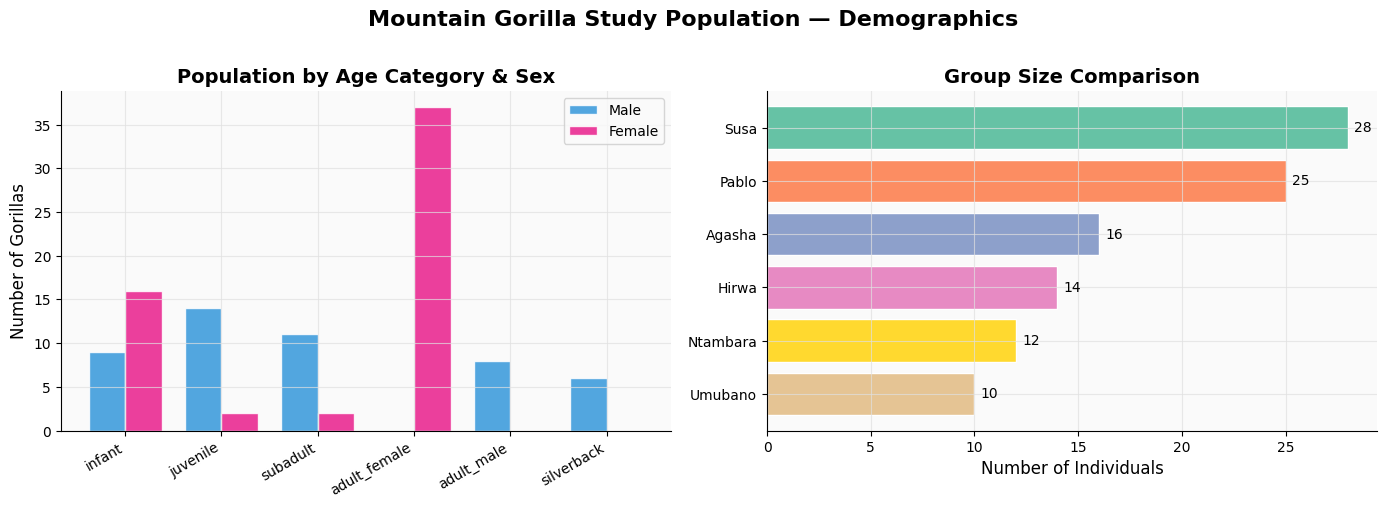

In [22]:
set_style()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Age category distribution by sex
age_sex = pd.crosstab(demographics_df['age_category'], demographics_df['sex'])
age_sex_ordered = age_sex.reindex([c for c in AGE_ORDER if c in age_sex.index])

x = np.arange(len(age_sex_ordered))
w = 0.38
axes[0].bar(x - w/2, age_sex_ordered.get('M', 0), w, label='Male',
            color='#3498DB', alpha=0.85, edgecolor='white')
axes[0].bar(x + w/2, age_sex_ordered.get('F', 0), w, label='Female',
            color='#E91E8C', alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(age_sex_ordered.index, rotation=30, ha='right')
axes[0].set_title('Population by Age Category & Sex')
axes[0].set_ylabel('Number of Gorillas')
axes[0].legend()

# Right: Group size comparison
group_sizes = demographics_df.groupby('group_id').size().sort_values(ascending=False)
colors_gs = plt.cm.Set2(np.linspace(0, 0.8, len(group_sizes)))
axes[1].barh(group_sizes.index, group_sizes.values, color=colors_gs, edgecolor='white')
for i, (group, size) in enumerate(group_sizes.items()):
    axes[1].text(size + 0.3, i, str(size), va='center', fontsize=10)
axes[1].set_xlabel('Number of Individuals')
axes[1].set_title('Group Size Comparison')
axes[1].invert_yaxis()

fig.suptitle('Mountain Gorilla Study Population — Demographics', y=1.01)
plt.tight_layout()
save_fig(fig, '02_population_demographics.png', str(FIG_DIR) + '/')
plt.show()

## Cell 6 — Tourist Visit Patterns

In [36]:
# ── Tourist visit statistics ───────────────────────────────────────────────────
print('=== TOURIST HEALTH SCREENING SUMMARY ===')
print(f'Total tourist-visit records: {len(tourist_health_df):,}')
print(f'Unique tourists:             {tourist_health_df["tourist_id"].nunique():,}')
print(f'Date range: {tourist_health_df["visit_date"].min().date()} to {tourist_health_df["visit_date"].max().date()}')

print(f'\nSymptom rate (overall): {tourist_health_df["had_symptoms"].mean():.1%}')
print(f'Pre-screened rate:       {tourist_health_df["pre_screened"].mean():.1%}')
print(f'Mask compliance:         {tourist_health_df["mask_compliant"].mean():.1%}')

print(f'\nSymptom rate by year:')
tourist_health_df['year'] = tourist_health_df['visit_date'].dt.year
yr_symptoms = tourist_health_df.groupby('year')['had_symptoms'].mean() * 100
print(yr_symptoms.round(1).to_string())

print(f'\nMasking compliance by year (note COVID policy shift 2020):')
yr_mask = tourist_health_df.groupby('year')['mask_compliant'].mean() * 100
print(yr_mask.round(1).to_string()) 

# Note: The sharp increase in symptom rates in 2020–2021 is likely due to heightened health screening and reporting during the COVID-19 pandemic, rather than an actual increase in symptomatic tourists.   
  

=== TOURIST HEALTH SCREENING SUMMARY ===
Total tourist-visit records: 65,502
Unique tourists:             65,502
Date range: 2015-01-01 to 2023-12-31

Symptom rate (overall): 7.5%
Pre-screened rate:       87.1%
Mask compliance:         61.9%

Symptom rate by year:
year
2015    7.3
2016    7.8
2017    7.8
2018    7.1
2019    7.5
2020    7.4
2021    7.3
2022    7.8
2023    7.5

Masking compliance by year (note COVID policy shift 2020):
year
2015    41.2
2016    41.6
2017    42.1
2018    42.0
2019    42.1
2020    87.1
2021    87.8
2022    87.2
2023    87.0


## Cell 7 — Tourist Volume & Symptom Rates Visualization

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/02_tourist_patterns.png


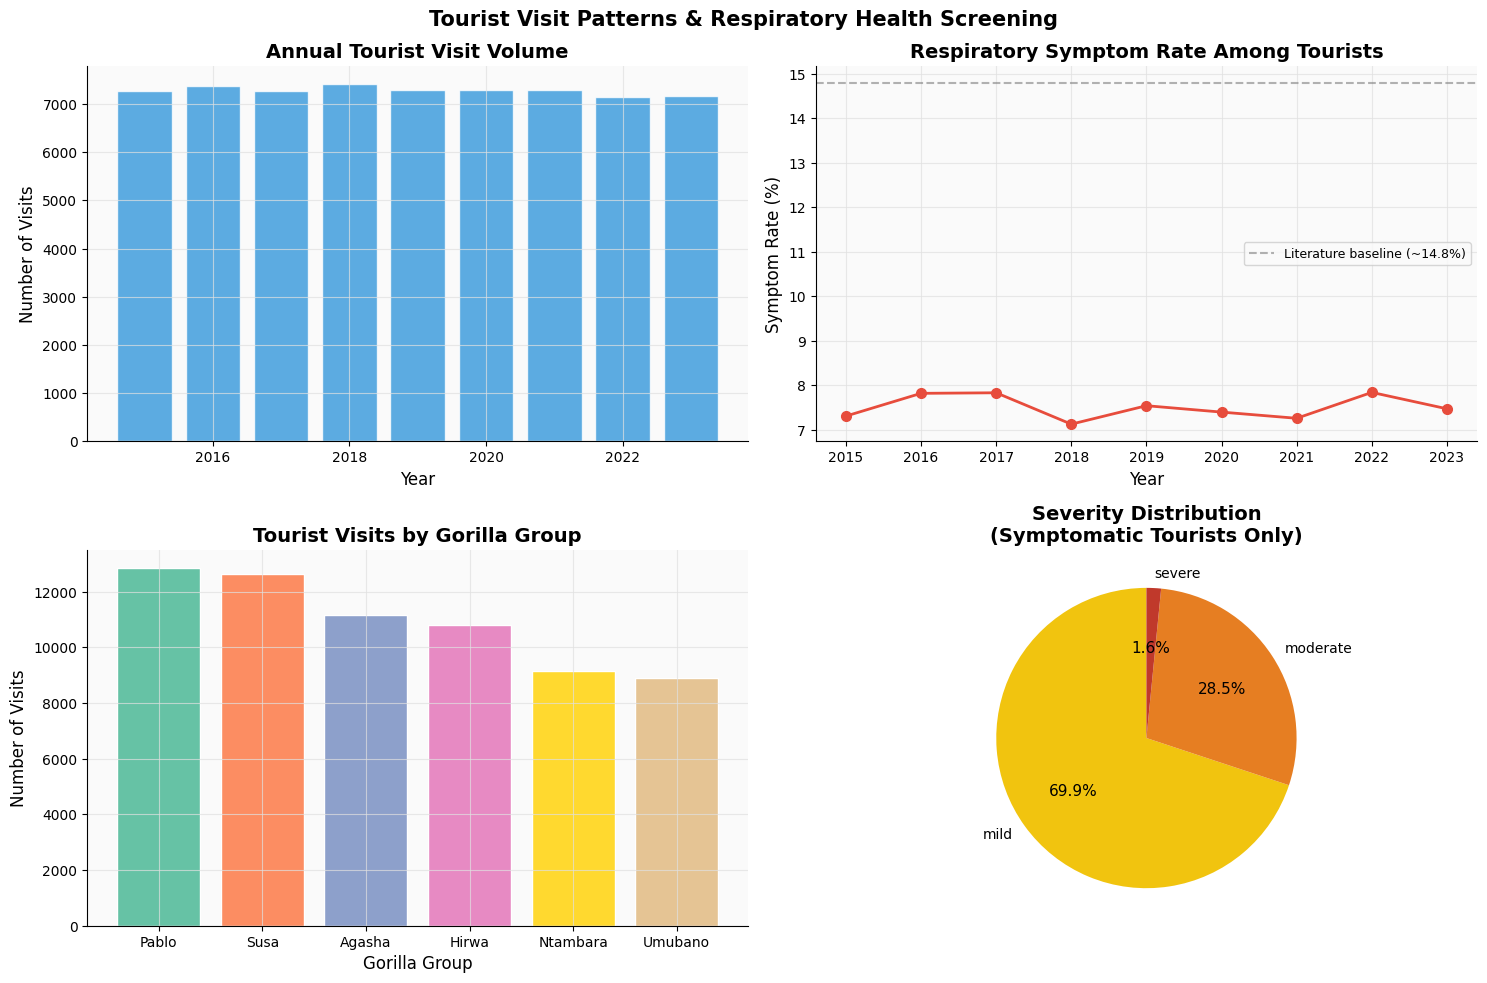

In [24]:
set_style()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Annual visit volume
annual_visits = tourist_health_df.groupby('year').size().reset_index(name='visits')
axes[0, 0].bar(annual_visits['year'], annual_visits['visits'],
                color='#3498DB', alpha=0.8, edgecolor='white')
axes[0, 0].set_title('Annual Tourist Visit Volume')
axes[0, 0].set_ylabel('Number of Visits')
axes[0, 0].set_xlabel('Year')

# Symptom rate by year
annual_symptoms = tourist_health_df.groupby('year')['had_symptoms'].mean() * 100
axes[0, 1].plot(annual_symptoms.index, annual_symptoms.values,
                 color='#E74C3C', marker='o', linewidth=2, markersize=7)
axes[0, 1].axhline(y=14.8, color='gray', linestyle='--', alpha=0.6, label='Literature baseline (~14.8%)')
axes[0, 1].set_title('Respiratory Symptom Rate Among Tourists')
axes[0, 1].set_ylabel('Symptom Rate (%)')
axes[0, 1].set_xlabel('Year')
axes[0, 1].legend(fontsize=9)

# Visit distribution by gorilla group
group_visits = tourist_health_df['group_visited'].value_counts()
axes[1, 0].bar(group_visits.index, group_visits.values,
                color=plt.cm.Set2(np.linspace(0, 0.8, len(group_visits))),
                edgecolor='white')
axes[1, 0].set_title('Tourist Visits by Gorilla Group')
axes[1, 0].set_ylabel('Number of Visits')
axes[1, 0].set_xlabel('Gorilla Group')

# Severity distribution of symptomatic tourists
sev_counts = tourist_health_df[tourist_health_df['had_symptoms']]['symptom_severity'].value_counts()
sev_colors = {'mild': '#F1C40F', 'moderate': '#E67E22', 'severe': '#C0392B'}
axes[1, 1].pie(
    sev_counts.values,
    labels=sev_counts.index,
    colors=[sev_colors.get(s, 'gray') for s in sev_counts.index],
    autopct='%1.1f%%',
    startangle=90,
)
axes[1, 1].set_title('Severity Distribution\n(Symptomatic Tourists Only)')

fig.suptitle('Tourist Visit Patterns & Respiratory Health Screening', fontsize=15)
plt.tight_layout()
save_fig(fig, '02_tourist_patterns.png', str(FIG_DIR) + '/')
plt.show()

## Cell 8 — Gorilla Health Events EDA

In [25]:
print('=== GORILLA HEALTH EVENTS SUMMARY ===')
print(f'Total illness events: {len(gorilla_health_df):,}')
print(f'Unique gorillas affected: {gorilla_health_df["gorilla_id"].nunique()}')
print(f'Groups: {gorilla_health_df["group_id"].nunique()}')

print(f'\nBy illness type:')
print(gorilla_health_df['illness_type'].value_counts().to_string())

print(f'\nBy severity:')
print(gorilla_health_df['severity'].value_counts().to_string())

print(f'\nBy transmission source:')
print(gorilla_health_df['transmission_source'].value_counts().to_string())

print(f'\nFatality rate: {(gorilla_health_df["severity"] == "fatal").mean():.1%}')
print(f'Recovery rate: {gorilla_health_df["recovered"].mean():.1%}')
print(f'Vet treatment rate: {gorilla_health_df["veterinary_treated"].mean():.1%}')

print(f'\nDays ill statistics:')
print(gorilla_health_df['days_ill'].describe().round(1).to_string())

=== GORILLA HEALTH EVENTS SUMMARY ===
Total illness events: 19,836
Unique gorillas affected: 99
Groups: 6

By illness type:
illness_type
respiratory         16124
gastrointestinal     1507
dermatological        985
injury                670
other                 550

By severity:
severity
mild        9676
moderate    6246
severe      2729
fatal       1185

By transmission source:
transmission_source
background_seasonal    13385
tourism_linked          3436
maternal_intragroup     3015

Fatality rate: 6.0%
Recovery rate: 94.0%
Vet treatment rate: 43.0%

Days ill statistics:
count    19836.0
mean        10.8
std          7.4
min          3.0
25%          6.0
50%          8.0
75%         15.0
max         35.0


## Cell 9 — Build Processed Datasets

In [26]:
# ── Enriched gorilla health dataset ───────────────────────────────────────────
gorilla_enriched = gorilla_health_df.merge(
    demographics_df[['gorilla_id', 'name', 'sex', 'age_years', 'age_category',
                      'group_id', 'immunocompromised', 'status', 'altitude_m']],
    on=['gorilla_id', 'group_id'],
    how='left'
)

# Add temporal features
gorilla_enriched['year']    = gorilla_enriched['event_date'].dt.year
gorilla_enriched['month']   = gorilla_enriched['event_date'].dt.month
gorilla_enriched['quarter'] = gorilla_enriched['event_date'].dt.quarter

# Merge climate conditions at event date
gorilla_enriched = gorilla_enriched.merge(
    climate_df[['date', 'season', 'rainfall_mm', 'temp_mean_c', 'humidity_pct']]
    .rename(columns={'date': 'event_date'}),
    on='event_date',
    how='left'
)

# Binary outcome variable for modeling
gorilla_enriched['is_respiratory'] = (gorilla_enriched['illness_type'] == 'respiratory').astype(int)
gorilla_enriched['is_severe']      = (gorilla_enriched['severity'].isin(['severe', 'fatal'])).astype(int)
gorilla_enriched['is_fatal']       = (gorilla_enriched['severity'] == 'fatal').astype(int)

print(f'Enriched gorilla health dataset: {gorilla_enriched.shape}')
print(gorilla_enriched.dtypes.to_string())

Enriched gorilla health dataset: (19836, 28)
event_id                           str
gorilla_id                         str
event_date              datetime64[us]
group_id                           str
illness_type                       str
severity                           str
days_ill                         int64
recovered                         bool
veterinary_treated                bool
transmission_source                str
linked_tourist_visit               str
name                               str
sex                                str
age_years                        int64
age_category                       str
immunocompromised                 bool
status                             str
altitude_m                       int64
year                             int32
month                            int32
quarter                          int32
season                             str
rainfall_mm                    float64
temp_mean_c                    float64
humidity_pct       

In [27]:
# ── Daily summary table ────────────────────────────────────────────────────────
# One row per day with counts for tourism, illness, climate
daily_illness = gorilla_health_df.groupby('event_date').agg(
    total_illness_events=('event_id', 'count'),
    respiratory_events=('illness_type', lambda x: (x == 'respiratory').sum()),
    tourism_linked_events=('transmission_source', lambda x: (x == 'tourism_linked').sum()),
    fatal_events=('severity', lambda x: (x == 'fatal').sum()),
).reset_index().rename(columns={'event_date': 'date'})

daily_tourists = tourist_health_df.groupby('visit_date').agg(
    total_tourists=('tourist_id', 'count'),
    symptomatic_tourists=('had_symptoms', 'sum'),
).reset_index().rename(columns={'visit_date': 'date'})

daily_summary = climate_df.merge(daily_illness, on='date', how='left')
daily_summary = daily_summary.merge(daily_tourists, on='date', how='left')

# Fill zeros for days with no events
fill_cols = ['total_illness_events', 'respiratory_events', 'tourism_linked_events',
             'fatal_events', 'total_tourists', 'symptomatic_tourists']
daily_summary[fill_cols] = daily_summary[fill_cols].fillna(0).astype(int)

print(f'Daily summary dataset: {daily_summary.shape}')
print(daily_summary.describe().round(2).to_string())

Daily summary dataset: (3287, 16)
                      date     year    month  day_of_year  rainfall_mm  temp_max_c  temp_min_c  temp_mean_c  humidity_pct  total_illness_events  respiratory_events  tourism_linked_events  fatal_events  total_tourists  symptomatic_tourists
count                 3287  3287.00  3287.00      3287.00      3287.00     3287.00     3287.00      3287.00       3287.00               3287.00             3287.00                3287.00       3287.00         3287.00               3287.00
mean   2019-07-02 00:00:00  2019.00     6.52       183.11         5.00       16.07        8.58        12.32         68.43                  6.03                4.90                   1.05          0.36           19.93                  1.50
min    2015-01-01 00:00:00  2015.00     1.00         1.00         0.00        9.50        3.00         7.60         41.50                  0.00                0.00                   0.00          0.00            0.00                  0.00
25%    201

## Cell 10 — Save Processed Datasets

In [28]:
# Save processed files
gorilla_enriched.to_csv(PROC_DIR / 'gorilla_health_enriched.csv', index=False)
daily_summary.to_csv(PROC_DIR / 'daily_summary.csv', index=False)
tourist_health_df.to_csv(PROC_DIR / 'tourist_enriched.csv', index=False)

print('=== PROCESSED FILES SAVED ===')
for f in sorted(PROC_DIR.glob('*.csv')):
    df_size = pd.read_csv(f).shape
    print(f'  {f.name:<40} shape={df_size}')

print('\n✅ Notebook 02 complete. Proceed to 03_date_proximity_linkage.ipynb')

=== PROCESSED FILES SAVED ===
  daily_summary.csv                        shape=(3287, 16)
  gorilla_health_enriched.csv              shape=(19836, 28)
  gorilla_health_linked.csv                shape=(19836, 19)
  linkage_summary_stats.csv                shape=(10, 2)
  tourist_enriched.csv                     shape=(65502, 14)

✅ Notebook 02 complete. Proceed to 03_date_proximity_linkage.ipynb
